# Dataset Exploration & Feature Engineering Plan
### Phase 1 — Week 1 — Task 2

Explores the cleaned dataset to understand its actual shape before writing
`build_interaction_matrix.py`. Every number here should directly inform
weighting decisions, cold-start thresholds, and what the content-based
fallback can realistically rely on.

**Set your path in the cell below, then run top to bottom.**

## 0. Path

In [1]:
INPUT_PATH = r"D:\Product-Recommendation-System\data\dataset\cleaned\cleaned_events.csv"

## 1. Imports & Load

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv(INPUT_PATH, parse_dates=["timestamp"])
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Rows: 5,588,982  |  Columns: 9


,timestamp,event_type,item_id,category_id,category_code,brand,price,user_id,session_id
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,electronics.smartphone,apple,"1,081.98",535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


## 2. Basic Structure

In [4]:
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

timestamp        datetime64[us, UTC]
event_type                       str
item_id                        int64
category_id                    int64
category_code                    str
brand                            str
price                        float64
user_id                        int64
session_id                       str
dtype: object

Missing values per column:
timestamp              0
event_type             0
item_id                0
category_id            0
category_code    1727528
brand             761289
price                  0
user_id                0
session_id             0
dtype: int64

Duplicate rows: 0


## 3. Volume & Uniqueness

In [5]:
n_users = df["user_id"].nunique()
n_items = df["item_id"].nunique()
n_events = len(df)

print(f"Unique users: {n_users:,}")
print(f"Unique items: {n_items:,}")
print(f"Total events: {n_events:,}")
print(f"Avg events per user: {n_events / n_users:.2f}")
print(f"Avg events per item: {n_events / n_items:.2f}")

# Matrix sparsity — what % of the user-item matrix is actually filled
possible_cells = n_users * n_items
actual_interactions = df.groupby(["user_id", "item_id"]).ngroups
sparsity = 1 - (actual_interactions / possible_cells)
print(f"\nInteraction matrix sparsity: {sparsity:.6%}")

Unique users: 670,980
Unique items: 105,963
Total events: 5,588,982
Avg events per user: 8.33
Avg events per item: 52.74

Interaction matrix sparsity: 99.995369%


## 4. Event Type Distribution
This directly determines your weighting scheme (`purchase=5, cart=3, click=1` from the plan) — confirm those numbers actually make sense against real proportions here.

              count   pct
event_type               
view        5376212 96.19
cart         114104  2.04
purchase      98666  1.77


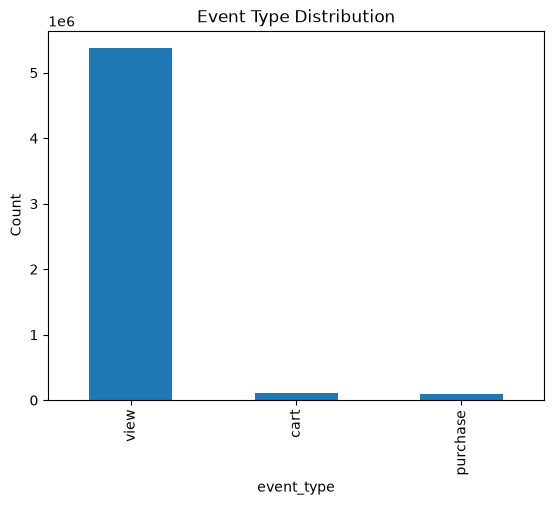

In [6]:
event_counts = df["event_type"].value_counts()
event_pct = df["event_type"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": event_counts, "pct": event_pct})
print(summary)

event_counts.plot(kind="bar", title="Event Type Distribution")
plt.ylabel("Count")
plt.show()

## 5. Interaction Sparsity — Events per User
Averages lie here. Check the median and the long tail — this is what tells you how big your cold-start population actually is.

count   670,980.00
mean          8.33
std          15.20
min           1.00
25%           2.00
50%           4.00
75%           9.00
max       1,222.00
dtype: float64
Users with <= 1 interactions: 24.9%
Users with <= 2 interactions: 39.0%
Users with <= 3 interactions: 49.1%
Users with <= 5 interactions: 62.4%
Users with <= 10 interactions: 78.7%


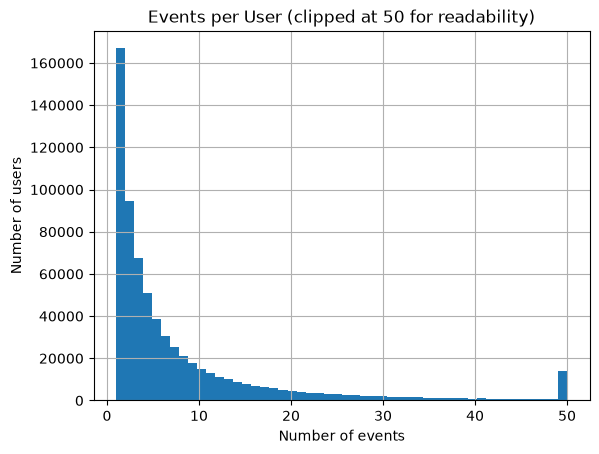

In [7]:
events_per_user = df.groupby("user_id").size()

print(events_per_user.describe())

for threshold in [1, 2, 3, 5, 10]:
    pct = (events_per_user <= threshold).mean() * 100
    print(f"Users with <= {threshold} interactions: {pct:.1f}%")

events_per_user.clip(upper=50).hist(bins=50)
plt.title("Events per User (clipped at 50 for readability)")
plt.xlabel("Number of events")
plt.ylabel("Number of users")
plt.show()

## 6. Interaction Sparsity — Events per Item

count   105,963.00
mean         52.74
std         535.10
min           1.00
25%           2.00
50%           7.00
75%          22.00
max      68,446.00
dtype: float64

Top 10 most-interacted items:
item_id
1004856    68446
1005115    59802
1004767    54454
1005105    33365
1004249    32616
1004870    32561
5100816    29768
4804056    29444
1004833    28692
1002544    28554
dtype: int64


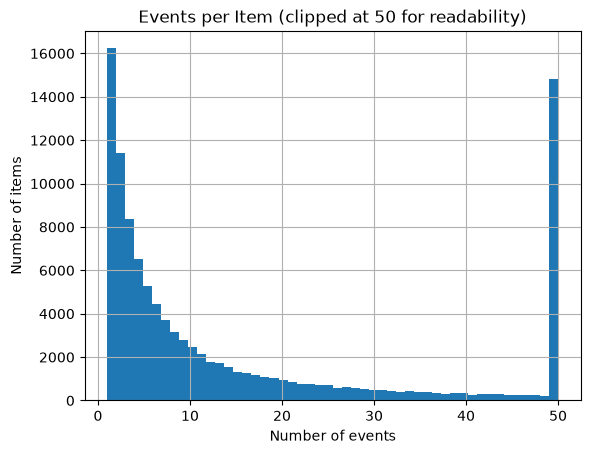

In [8]:
events_per_item = df.groupby("item_id").size()

print(events_per_item.describe())

top_items = events_per_item.sort_values(ascending=False).head(10)
print("\nTop 10 most-interacted items:")
print(top_items)

events_per_item.clip(upper=50).hist(bins=50)
plt.title("Events per Item (clipped at 50 for readability)")
plt.xlabel("Number of events")
plt.ylabel("Number of items")
plt.show()

## 7. Category & Brand Completeness
Feeds directly into how reliable your TF-IDF content-based fallback can be. If a large chunk of rows have neither field, the fallback needs a plan B (e.g. `category_id` alone, or global popularity).

In [9]:
cat_missing_pct = df["category_code"].isna().mean() * 100
brand_missing_pct = df["brand"].isna().mean() * 100
both_missing_pct = (df["category_code"].isna() & df["brand"].isna()).mean() * 100

print(f"% rows missing category_code: {cat_missing_pct:.1f}%")
print(f"% rows missing brand:         {brand_missing_pct:.1f}%")
print(f"% rows missing BOTH:          {both_missing_pct:.1f}%")

print("\nTop 10 categories by event count:")
print(df["category_code"].value_counts().head(10))

% rows missing category_code: 30.9%
% rows missing brand:         13.6%
% rows missing BOTH:          8.6%

Top 10 categories by event count:
category_code
electronics.smartphone              1580779
electronics.clocks                   194755
computers.notebook                   168634
electronics.audio.headphone          151999
electronics.video.tv                 131559
appliances.kitchen.washer            113106
appliances.kitchen.refrigerators     110625
appliances.environment.vacuum        107962
auto.accessories.player               78929
apparel.shoes                         67903
Name: count, dtype: int64


## 8. Session Analysis
Matters for the real-time re-ranking layer — sessions with only 1-2 events don't give the bandit much to work with.

count   1,203,800.00
mean            4.64
std             6.72
min             1.00
25%             1.00
50%             2.00
75%             5.00
max           643.00
dtype: float64
Sessions with <= 1 events: 34.2%
Sessions with <= 2 events: 51.1%
Sessions with <= 3 events: 62.4%
Sessions with <= 5 events: 76.0%


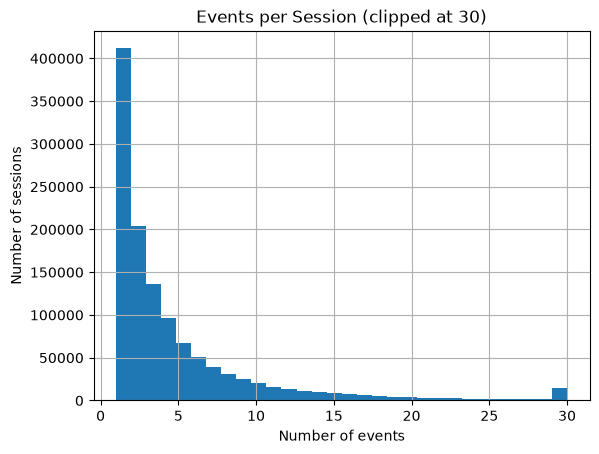

In [10]:
events_per_session = df.groupby("session_id").size()

print(events_per_session.describe())

for threshold in [1, 2, 3, 5]:
    pct = (events_per_session <= threshold).mean() * 100
    print(f"Sessions with <= {threshold} events: {pct:.1f}%")

events_per_session.clip(upper=30).hist(bins=30)
plt.title("Events per Session (clipped at 30)")
plt.xlabel("Number of events")
plt.ylabel("Number of sessions")
plt.show()

## 9. Temporal Patterns

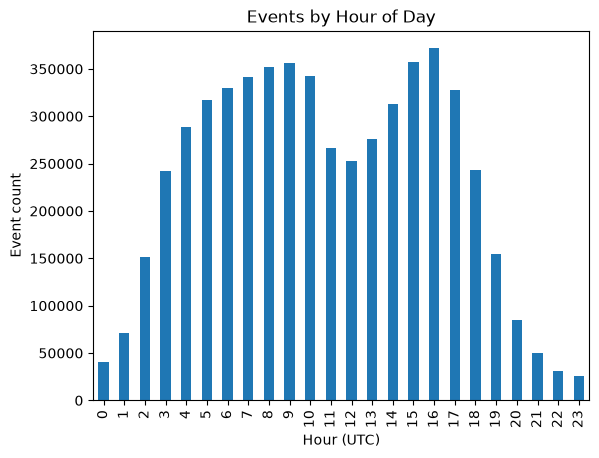

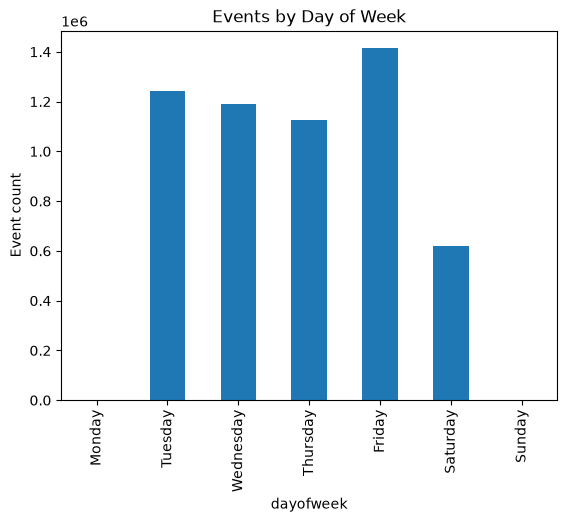

In [11]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["dayofweek"] = df["timestamp"].dt.day_name()

df.groupby("hour").size().plot(kind="bar", title="Events by Hour of Day")
plt.xlabel("Hour (UTC)")
plt.ylabel("Event count")
plt.show()

df.groupby("dayofweek").size().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
).plot(kind="bar", title="Events by Day of Week")
plt.ylabel("Event count")
plt.show()

## 10. Findings — fill this in after running everything above

**Volume**

- Unique users: 670,980
- Unique items: 105,963
- Total events: 5,588,982
- Matrix sparsity: 99.9995369%

**Event type distribution**

- view: 96.19% | cart: 2.04% | purchase: 1.77% | remove_from_cart: 0%
- Does this justify the planned weighting (purchase=5, cart=3, click=1)? Yes. Views dominate the dataset, while cart and purchase events are much stronger indicators of user intent. The weighting therefore appropriately gives greater importance to higher-intent interactions.

**Cold-start sizing**

- % of users with <=1 interaction: 24.9%
- % of users with <=3 interactions: 49.1%
- Decision: cold-start threshold = 3 interactions

**Category/brand completeness**

- % missing category_code: 30.9%
- % missing brand: 13.6%
- Fallback plan for rows missing both: Use popularity-based or global item recommendations instead of relying on metadata-based recommendations.

**Session quality**

- Median events per session: Not calculated in current EDA
- % sessions with <=2 events: Not calculated in current EDA
- Implication for real-time re-ranking: Short sessions provide limited behavioural information, so real-time re-ranking should rely on recent interactions only when sufficient session history is available and otherwise fall back to user history or popularity.

**Temporal patterns**

- Peak activity hour(s): Approximately 15:00–16:00 UTC
- Any notable day-of-week pattern: Friday has the highest observed activity, while Saturday is substantially lower. Activity varies noticeably across the week.

**Data quality issues noticed**

- 30.9% of rows are missing category_code
- 13.6% of rows are missing brand
- 8.6% of rows are missing both category_code and brand
- Event distribution is highly imbalanced toward view events
- User-item interaction matrix is extremely sparse
- User and item interaction counts have strong long-tail distributions
- No duplicate rows were detected
- Core fields such as timestamp, event_type, item_id and user_id contain no missing values

---

## 11. Feature Engineering Plan (draft)

Based on the findings above:

- [ ] Event weighting scheme: purchase=_, cart=_, click=_, view=_
- [ ] Cold-start threshold: users with <= _ interactions get content-based fallback
- [ ] Content-based fallback input: category_code + brand (with fallback to category_id when both missing)
- [ ] Time-decay weighting: yes/no — if yes, decay function: _
- [ ] Minimum session length for real-time re-ranking to activate: _
- [ ] Any items to exclude (e.g. extremely low interaction count, outlier prices): _